# Notebook 4 — M2: Quality Scorer (LLM sobre texto de listings)

**Real Estate Intelligence Platform (REIP)**

Construimos un scorer de calidad de anuncio basado en LLM que evalúa el texto de `descripcion`
de cada listing en cuatro dimensiones: completitud informativa, calidad de presentación/redacción,
diferenciadores/amenidades comunicados y transparencia de precio. A diferencia de los notebooks
2 y 3 (M2 de tipo Entrenamiento, con métricas de error como MAE o Silhouette), este notebook es de
tipo Experimentación: no hay una métrica de error que minimizar, sino un proceso de diseño e
iteración de prompt que documentamos como evidencia del método.

## Verificación de entorno y rutas

Confirmamos la convención ya establecida en 6.2.3 (Notebook 1): `.env` vive en la raíz del repo,
no en `notebooks/`, y el kernel corre con `cwd = notebooks/`, así que usamos
`find_dotenv(usecwd=True)` en vez de `load_dotenv()` simple. El dataset de entrada es
`pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv` (Notebook 6.2.1) y los artifacts
de este notebook van a `pipeline/models/`, siguiendo la misma convención que 6.2.3/6.2.4/6.2.5.

In [1]:
import sys
import os
import json
import time
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

RUTA_CATALOGO = REPO_ROOT / "pipeline" / "data" / "processed" / "catalogo_residencial_limpio_6_2_1.csv"
RUTA_MODELOS = REPO_ROOT / "pipeline" / "models"
assert RUTA_CATALOGO.exists(), f"No existe {RUTA_CATALOGO}"
RUTA_MODELOS.mkdir(exist_ok=True)

RUTA_CHECKPOINT = RUTA_MODELOS / "quality_scores_6_2_6_checkpoint.pkl"
RUTA_CHECKPOINT_DIAG_V1 = RUTA_MODELOS / "quality_scores_6_2_6_diag_v1_checkpoint.pkl"
RUTA_CHECKPOINT_DIAG_V2 = RUTA_MODELOS / "quality_scores_6_2_6_diag_v2_checkpoint.pkl"
RUTA_FINAL = RUTA_MODELOS / "quality_scores_6_2_6_raw.pkl"

def cargar_checkpoint_generico(ruta):
    if ruta.exists():
        with open(ruta, "rb") as f:
            return pickle.load(f)
    return {}

def guardar_checkpoint_generico(ruta, resultados):
    with open(ruta, "wb") as f:
        pickle.dump(resultados, f)

from dotenv import load_dotenv, find_dotenv
ruta_env = find_dotenv(usecwd=True)
assert ruta_env, "No se encontró .env en el árbol de directorios"
load_dotenv(ruta_env)

assert os.environ.get("GEMINI_API_KEY"), "GEMINI_API_KEY no está cargada"
print(".env cargado desde:", ruta_env)

RANDOM_STATE = 42

.env cargado desde: /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/.env


## Confirmación del modelo LLM contra la API real

`CLAUDE.md` declara Gemini 2.5 Flash como modelo de NLP del proyecto (M3). Siguiendo la misma
regla que ya produjo un hallazgo real en 6.2.3 (el nombre de modelo de embeddings documentado
públicamente estaba desactualizado), confirmamos el nombre exacto del modelo contra la API real —
pero esta vez con una llamada de prueba real, no solo contra `client.models.list()`. Esa lista
resultó ser engañosa: incluye modelos que aparecen como soportando `generateContent` pero que
devuelven 404 al invocarlos.

**Hallazgo 1:** `gemini-2.5-flash` (el nombre declarado en `CLAUDE.md`) figura en
`client.models.list()`, pero una llamada real devuelve `404 NOT_FOUND` con el mensaje "This model
... is no longer available to new users". El mismo problema aparece en `gemini-2.5-flash-lite` y
`gemini-2.0-flash`. `client.models.list()` no es una fuente confiable de disponibilidad real —
solo una llamada de prueba lo confirma.

**Hallazgo 2:** el alias `gemini-flash-latest` sí responde, pero es explícitamente móvil — Google
puede reapuntarlo a otra versión sin aviso, lo cual lo hace inadecuado para citar en un documento
académico reproducible. Inspeccionamos qué modelo real resuelve detrás del alias con
`resp.model_version` (metadata de la propia respuesta, no un campo documentado a asumir) y
encontramos `gemini-3.5-flash`, con identificador de versión fijo `3.5-flash-05-2026` reportado
por `client.models.get()`. Usamos ese nombre de modelo directo, no el alias, para que la corrida
sea citable con una versión concreta.

**Hallazgo 3 (decisión final):** `gemini-3.5-flash`, aunque confirmado con un identificador de
versión fijo, mostró disponibilidad degradada sostenida durante la ejecución real de este
notebook — no un corte puntual. Verificamos esto de forma explícita, no lo asumimos de un solo
fallo: un lote completo de 25 llamadas de diagnóstico (con reintento corto ya aplicado a cada una)
devolvió `503 UNAVAILABLE`/`504 DEADLINE_EXCEEDED` en el 100% de los casos, sostenido a lo largo de
varias horas de intentos en distintos momentos del día. Ante esa evidencia, decidimos usar
`gemini-3-flash-preview` como modelo final de este notebook. **Limitación metodológica explícita:**
es un modelo en estado "preview" — Google puede retirarlo o cambiar su comportamiento sin aviso,
a diferencia de un modelo GA con versión fija como el que buscábamos originalmente. Los resultados
recolectados antes de este cambio (bajo `gemini-3.5-flash`) se conservan y quedan etiquetados por
fila con el modelo real que los generó -- no se descartan ni se mezclan sin distinción.

In [2]:
from google import genai
from google.genai import types, errors

client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"],
    http_options=types.HttpOptions(timeout=45_000),
)
# Sin este timeout explicito (ms), el cliente hereda timeout=None de httpx -- una conexion
# estancada (observamos varias en este entorno) cuelga indefinidamente en vez de fallar rapido
# hacia nuestra propia logica de reintento/circuit breaker.

CANDIDATOS_LLM = ["gemini-2.5-flash", "gemini-flash-latest", "gemini-3.5-flash", "gemini-3-flash-preview"]
disponibles = {}
for candidato in CANDIDATOS_LLM:
    try:
        resp = client.models.generate_content(model=candidato, contents="prueba de disponibilidad")
        disponibles[candidato] = f"OK (model_version={resp.model_version})"
    except errors.APIError as e:
        disponibles[candidato] = f"{e.code} {e.status}"

for candidato, estado in disponibles.items():
    print(f"{candidato}: {estado}")

# Decision final (ver Hallazgo 3): gemini-3.5-flash mostro 100% de fallo sostenido en un lote
# completo de diagnostico durante la ejecucion real -- cambiamos a gemini-3-flash-preview.
MODELO_LLM = "gemini-3-flash-preview"
info_modelo = client.models.get(model=MODELO_LLM)
print(f"\nModelo final usado en este notebook: {MODELO_LLM} (version={info_modelo.version}) -- "
      "modelo de contingencia permanente tras disponibilidad degradada sostenida de "
      "gemini-3.5-flash (ver Hallazgo 3). Es un modelo 'preview', no GA -- limitacion "
      "metodologica explicita, documentada tambien en el cierre de este notebook.")

gemini-2.5-flash: 404 NOT_FOUND
gemini-flash-latest: OK (model_version=gemini-3.5-flash)
gemini-3.5-flash: 503 UNAVAILABLE
gemini-3-flash-preview: OK (model_version=gemini-3-flash-preview)

Modelo final usado en este notebook: gemini-3-flash-preview (version=3-flash-preview-12-2025) -- modelo de contingencia permanente tras disponibilidad degradada sostenida de gemini-3.5-flash (ver Hallazgo 3). Es un modelo 'preview', no GA -- limitacion metodologica explicita, documentada tambien en el cierre de este notebook.


## Decisión: no usamos la batch API del SDK

Verificamos si `google-genai` (2.11.0) ofrece batching real antes de decidir el patrón de
llamadas, en vez de asumir que solo existe el modo de una request a la vez. El SDK sí expone
`client.batches.create()`, pero es un mecanismo de **job asíncrono** (fuente: `.jobId`/`BatchJob`
con estado consultable por polling, pensado para cargas masivas con SLA de procesamiento por
lotes, no de respuesta inmediata) — no es una forma de agrupar varias requests síncronas en una
sola llamada de baja latencia. Para este notebook, donde necesitamos correr un subconjunto
pequeño, leer el resultado, ajustar el prompt y volver a correrlo varias veces, un job asíncrono
de horas de SLA no es compatible con el ciclo de iteración. Decidimos usar `generate_content`
síncrono, una request por listing, con espaciado entre llamadas y un circuit breaker ante 429 —
no es batching real porque no lo hay disponible en la forma que este notebook necesita, es una
decisión verificada, no una omisión.

## 1. Carga del catálogo y decisión de filtrado

A diferencia de los Notebooks 2 y 3 (M2 KNN/RF/KMeans), que excluyen `zona_no_determinada` y
`precio_no_evaluable` porque dependen de zona y precio como features del modelo, el Quality
Scorer evalúa la calidad del texto del anuncio en sí — no el valor de mercado ni la zona. Por lo
tanto **no excluimos esas filas** de la población evaluable: un listing sin zona resuelta o con
precio fuera de umbral de dominio puede tener una `descripcion` perfectamente evaluable.

La única exclusión real es `descripcion_fuente == "ninguna"` (9 filas, 0.76% del catálogo): no
hay texto que evaluar, así que estas filas quedan marcadas explícitamente como **no evaluables**
en vez de forzar un score sobre texto inexistente.

Para la dimensión 4 (transparencia de precio) sí pasamos `price_usd` como contexto al LLM incluso
en filas con `precio_no_evaluable == True` — el LLM juzga si el precio está presentado de forma
clara y coherente con el texto, que es una pregunta distinta a si ese precio es plausible para el
mercado (esa validación de dominio es responsabilidad de M2 KNN/RF, no de este notebook).

In [3]:
df_catalogo = pd.read_csv(RUTA_CATALOGO)
total = len(df_catalogo)

no_evaluables = df_catalogo[df_catalogo["descripcion_fuente"] == "ninguna"]
df_evaluable = df_catalogo[df_catalogo["descripcion_fuente"] != "ninguna"].copy()

print(f"Catálogo total: {total} filas")
print(f"No evaluables (sin texto de descripción): {len(no_evaluables)} filas "
      f"({len(no_evaluables) / total:.2%})")
print(f"Población evaluable por el Quality Scorer: {len(df_evaluable)} filas "
      f"({len(df_evaluable) / total:.2%})")
df_evaluable["descripcion_fuente"].value_counts()

Catálogo total: 1177 filas
No evaluables (sin texto de descripción): 9 filas (0.76%)
Población evaluable por el Quality Scorer: 1168 filas (99.24%)


descripcion_fuente
completa    1137
preview       31
Name: count, dtype: int64

## 2. Definición de la muestra representativa

Este notebook es de tipo Experimentación: no necesitamos correr el catálogo completo (1,168 filas
evaluables), pero la muestra sí debe ser lo bastante grande para leer una distribución defendible
de los 4 scores. Elegimos `n = 150` por muestreo aleatorio simple (semilla fija) sobre la
población evaluable. Con `N = 1,168`, el margen de error para una proporción al 95% de confianza
(caso conservador `p = 0.5`, con corrección por población finita) es:

In [4]:
N = len(df_evaluable)
n = 150

moe = 1.96 * np.sqrt(0.25 / n) * np.sqrt((N - n) / (N - 1))
print(f"N = {N}, n = {n}")
print(f"Margen de error (95% CI, p=0.5, con FPC): ±{moe:.2%}")

df_muestra = df_evaluable.sample(n=n, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"\nDistribución de la muestra por corregimiento:")
print(df_muestra["corregimiento"].value_counts(normalize=True).round(3))

N = 1168, n = 150
Margen de error (95% CI, p=0.5, con FPC): ±7.47%

Distribución de la muestra por corregimiento:
corregimiento
San Francisco          0.387
Bella Vista            0.207
Costa del Este         0.127
Betania                0.073
El Cangrejo            0.060
Marbella               0.053
Obarrio                0.040
zona_no_determinada    0.033
Parque Lefevre         0.020
Name: proportion, dtype: float64


±7.5% de margen de error al 95% de confianza es aceptable para una lectura exploratoria de
distribución (no para un intervalo de confianza que alimente una decisión de producto), que es el
uso que le damos a este notebook.

## 3. Esquema de salida y diseño de prompt

Definimos el esquema de salida esperado — 4 scores enteros de 1 a 5, uno por dimensión — como un
modelo Pydantic, para poder usarlo tanto en la validación manual (prompt v1) como en el modo de
salida estructurada del SDK (prompt v2).

In [5]:
from pydantic import BaseModel, Field, ValidationError

class QualityScore(BaseModel):
    completitud_informativa: int = Field(ge=1, le=5)
    calidad_presentacion: int = Field(ge=1, le=5)
    diferenciadores_amenidades: int = Field(ge=1, le=5)
    transparencia_precio: int = Field(ge=1, le=5)

RUBRICA = """Evalúas la calidad de un anuncio inmobiliario en 4 dimensiones, cada una en escala
de 1 (muy débil) a 5 (excelente):

1. completitud_informativa: ¿el texto da información real y específica (área, características,
   ubicación concreta) o es vago/genérico ("excelente oportunidad", sin datos verificables)?
2. calidad_presentacion: profesionalismo y claridad de la redacción — puntuación, estructura,
   ausencia de errores obvios o texto tipo spam/relleno repetido.
3. diferenciadores_amenidades: ¿comunica valor agregado real y específico (vista, acabados,
   amenidades concretas) o solo adjetivos genéricos sin sustancia ("lujoso", "excelente")?
4. transparencia_precio: dado el precio de referencia provisto, ¿el texto presenta el precio de
   forma clara y coherente con lo descrito (o, si el anuncio tiene varios modelos/unidades,
   explica el rango de forma comprensible)? Un texto que no menciona precio en absoluto, cuando
   se te da un precio de referencia, es baja transparencia aunque el resto del anuncio sea bueno.
"""

def construir_prompt(fila):
    precio_ctx = (
        f"${fila['price_usd']:,.0f}" if pd.notna(fila["price_usd"]) else "no disponible"
    )
    return f"""{RUBRICA}

Anuncio a evaluar:
Título: {fila['title']}
Tipo de inmueble: {fila['tipo_inmueble']}
Precio de referencia (dato del scraper, no necesariamente mencionado en el texto): {precio_ctx}
Área: {fila['area_m2']} m² | Habitaciones: {fila['bedrooms']} | Baños: {fila['bathrooms']}

Descripción del anuncio:
{fila['descripcion'][:4000]}
"""


## 4. Prompt v1 — salida en texto libre, parseo manual

La primera versión pide el JSON dentro del texto de la respuesta, sin modo de salida estructurada
del SDK, y lo parseamos manualmente (con `json.loads` y un intento de recorte si el modelo agrega
texto o fences de markdown alrededor). Corremos esta versión sobre un subconjunto pequeño de
diagnóstico (`n_diag = 25`, no la muestra completa) para medir la tasa de parseo antes de comprometer
la muestra completa a un prompt sin validar.

In [6]:
PROMPT_V1_SUFIJO = """

Responde ÚNICAMENTE con un objeto JSON con las claves exactas: completitud_informativa,
calidad_presentacion, diferenciadores_amenidades, transparencia_precio (enteros de 1 a 5)."""

def parsear_json_manual(texto):
    texto = texto.strip()
    if texto.startswith("```"):
        texto = texto.split("```")[1]
        if texto.startswith("json"):
            texto = texto[4:]
    inicio = texto.find("{")
    fin = texto.rfind("}")
    if inicio == -1 or fin == -1:
        return None
    try:
        return json.loads(texto[inicio:fin + 1])
    except json.JSONDecodeError:
        return None

def llamar_con_reintento_red(fn_llamada, max_reintentos_red=1):
    # Envoltura comun: un solo reintento corto ante errores de transporte (conexion
    # reiniciada, timeout de socket) que no son errores de la API (errors.APIError) sino
    # cortes de red puntuales -- observamos mas de uno en este entorno durante la corrida.
    intentos_red = 0
    while True:
        try:
            return fn_llamada()
        except errors.APIError:
            raise
        except Exception:
            if intentos_red < max_reintentos_red:
                intentos_red += 1
                time.sleep(5)
                continue
            raise

df_diagnostico = df_evaluable.sample(n=25, random_state=RANDOM_STATE)

resultados_v1 = cargar_checkpoint_generico(RUTA_CHECKPOINT_DIAG_V1)
print(f"Checkpoint de diagnóstico v1 existente: {len(resultados_v1)} listings ya evaluados")

for _, fila in df_diagnostico.iterrows():
    lid = fila["listing_id"]
    if resultados_v1.get(lid, {}).get("valido"):
        # Solo saltamos entradas ya *validas* -- una entrada que fallo en un intento anterior
        # (ej. por un 503 transitorio del modelo) se reintenta, no se descarta para siempre.
        continue
    prompt = construir_prompt(fila) + PROMPT_V1_SUFIJO
    try:
        resp = llamar_con_reintento_red(
            lambda: client.models.generate_content(model=MODELO_LLM, contents=prompt)
        )
        parseado = parsear_json_manual(resp.text or "")
        valido = False
        if parseado is not None:
            try:
                QualityScore(**parseado)
                valido = True
            except (ValidationError, TypeError):
                valido = False
        resultados_v1[lid] = {"parseado": parseado is not None, "valido": valido}
    except Exception as e:
        resultados_v1[lid] = {"parseado": False, "valido": False, "error": str(e)}
    guardar_checkpoint_generico(RUTA_CHECKPOINT_DIAG_V1, resultados_v1)
    time.sleep(1)

df_v1 = pd.DataFrame([{"listing_id": lid, **r} for lid, r in resultados_v1.items()])
tasa_v1 = df_v1["valido"].mean()
print(f"Prompt v1 — JSON parseado y válido contra el esquema: {tasa_v1:.1%} ({df_v1['valido'].sum()}/{len(df_v1)})")

Checkpoint de diagnóstico v1 existente: 25 listings ya evaluados


Prompt v1 — JSON parseado y válido contra el esquema: 100.0% (25/25)


## 5. Prompt v2 (final) — salida estructurada del SDK

Si la tasa de v1 cae bajo el umbral de ~90% ya establecido en 6.2.3, iteramos: en vez de pedir el
JSON como texto libre, usamos `response_mime_type="application/json"` + `response_schema` del SDK
para forzar la forma de la respuesta a nivel de API, y seguimos validando con Pydantic (un JSON
sintácticamente válido que viole el rango 1-5 todavía cuenta como fallo). Confirmamos la tasa
resultante sobre el mismo subconjunto de diagnóstico antes de comprometer la muestra completa.

**Nivel de razonamiento (`thinking_level`):** confirmamos contra el SDK que
`types.ThinkingConfig` expone `thinking_level` con valores `MINIMAL`/`LOW`/`MEDIUM`/`HIGH` (el
default del modelo, sin configurar, es `MEDIUM`). Esta tarea es clasificación estructurada de 4
scores discretos sobre un texto ya provisto -- no requiere razonamiento multi-paso ni cadenas de
inferencia largas -- así que usamos `LOW` en vez del default: reduce tokens de salida dedicados a
razonamiento interno (y por lo tanto latencia y costo) sin que la tarea lo necesite. No usamos
`MINIMAL` para dejar algo de margen de razonamiento dado que el prompt sí pide comparar el precio
de referencia contra el texto libre, una inferencia mínima pero no trivial.

In [7]:
config_v2 = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema=QualityScore,
    thinking_config=types.ThinkingConfig(thinking_level=types.ThinkingLevel.LOW),
)

CODIGOS_CONTENCION_CAPACIDAD = (503, 504)  # high demand / deadline expired -- no es cuota propia

def llamar_v2(fila, modelo=None, max_reintentos_429=1, max_reintentos_capacidad=1):
    modelo = modelo or MODELO_LLM
    prompt = construir_prompt(fila)
    intentos_429 = 0
    intentos_capacidad = 0
    while True:
        try:
            resp = llamar_con_reintento_red(
                lambda: client.models.generate_content(model=modelo, contents=prompt, config=config_v2)
            )
            data = json.loads(resp.text)
            score = QualityScore(**data)
            return score, None
        except errors.APIError as e:
            if e.code == 429 and intentos_429 < max_reintentos_429:
                intentos_429 += 1
                time.sleep(90)
                continue
            if e.code in CODIGOS_CONTENCION_CAPACIDAD and intentos_capacidad < max_reintentos_capacidad:
                # 503 ("high demand") y 504 (deadline expirado del lado del servidor) son
                # contencion de capacidad del modelo, no un limite de cuota propio -- un
                # reintento corto (no 90s) es razonable, distinto del circuit breaker de 429.
                intentos_capacidad += 1
                time.sleep(20)
                continue
            return None, str(e)
        except (ValidationError, json.JSONDecodeError, TypeError) as e:
            return None, str(e)
        except Exception as e:
            return None, f"{type(e).__name__}: {e}"

resultados_v2 = cargar_checkpoint_generico(RUTA_CHECKPOINT_DIAG_V2)
print(f"Checkpoint de diagnóstico v2 existente: {len(resultados_v2)} listings ya evaluados")

for _, fila in df_diagnostico.iterrows():
    lid = fila["listing_id"]
    if resultados_v2.get(lid, {}).get("valido"):
        continue
    score, error = llamar_v2(fila)
    resultados_v2[lid] = {"valido": score is not None, "error": error}
    guardar_checkpoint_generico(RUTA_CHECKPOINT_DIAG_V2, resultados_v2)
    time.sleep(1)

df_v2 = pd.DataFrame([{"listing_id": lid, **r} for lid, r in resultados_v2.items()])
tasa_v2 = df_v2["valido"].mean()
print(f"Prompt v2 (salida estructurada) — válido contra el esquema: {tasa_v2:.1%} ({df_v2['valido'].sum()}/{len(df_v2)})")
assert tasa_v2 >= 0.90, "La tasa de parseo de v2 sigue bajo 90% -- requiere otra iteración antes de correr la muestra completa"
print("Umbral de 90% alcanzado -- procedemos con la muestra completa usando el prompt v2.")

Checkpoint de diagnóstico v2 existente: 25 listings ya evaluados
Prompt v2 (salida estructurada) — válido contra el esquema: 100.0% (25/25)
Umbral de 90% alcanzado -- procedemos con la muestra completa usando el prompt v2.


**Comparación v1 vs. v2:** la salida estructurada del SDK (`response_schema`) elimina la
fuente de error más común en v1 — texto adicional alrededor del JSON o fences de markdown que
rompen un parseo ingenuo — porque la validación de forma ocurre en la API, no después. La
validación Pydantic se mantiene igual en ambas versiones porque un JSON con forma correcta puede
seguir teniendo valores fuera del rango 1-5.

## 6. Corrida completa sobre la muestra (n=150) con checkpoint incremental y circuit breaker

Guardamos progreso en cada llamada a un checkpoint en `pipeline/models/` (no en un directorio
efímero) para no perder la corrida si falla a mitad de camino. Ante un 429 no reintentamos con
backoff creciente: paramos en el primer fallo, esperamos ~90s, reintentamos una vez, y si vuelve a
fallar detenemos la corrida y la reportamos en vez de insistir contra un límite que puede no
resolverse rápido.

Durante la ejecución observamos tres clases de fallo transitorio adicionales, distintas de un 429
de cuota propia: `503 UNAVAILABLE` y `504 DEADLINE_EXCEEDED` (contención de capacidad del lado del
modelo, no de nuestra cuota) y errores de transporte a nivel de conexión (`ConnectionResetError`
sobre el socket, y conexiones que se quedan colgadas indefinidamente sin un timeout explícito del
cliente). Los tres son puntuales, no indicativos de un límite persistente, así que reciben un solo
reintento con espera corta (20s para 503/504, 5s para errores de transporte) en vez del circuit
breaker de 90s reservado para 429. También fijamos `http_options=types.HttpOptions(timeout=45_000)`
al construir el cliente -- sin este timeout explícito, una conexión colgada no genera ninguna
excepción y bloquea la corrida indefinidamente en vez de caer en el reintento.

In [8]:
def cargar_checkpoint():
    if RUTA_CHECKPOINT.exists():
        with open(RUTA_CHECKPOINT, "rb") as f:
            return pickle.load(f)
    return {}

def guardar_checkpoint(resultados):
    with open(RUTA_CHECKPOINT, "wb") as f:
        pickle.dump(resultados, f)

resultados_muestra = cargar_checkpoint()
print(f"Checkpoint existente: {len(resultados_muestra)} listings ya evaluados")

MODELO_ACTIVO = MODELO_LLM

detenido_por_429 = False
for _, fila in df_muestra.iterrows():
    lid = fila["listing_id"]
    if resultados_muestra.get(lid, {}).get("score") is not None:
        continue
    score, error = llamar_v2(fila, modelo=MODELO_ACTIVO)
    if score is None and error and "429" in error:
        detenido_por_429 = True
        print(f"Circuit breaker: 429 persistente en listing {lid} tras reintento. Deteniendo corrida.")
        break
    resultados_muestra[lid] = {
        "score": score.model_dump() if score is not None else None,
        "error": error,
        "modelo": MODELO_ACTIVO,
    }
    guardar_checkpoint(resultados_muestra)
    time.sleep(1)

print(f"\nTotal evaluados en checkpoint: {len(resultados_muestra)} / {len(df_muestra)}")
if detenido_por_429:
    print("ADVERTENCIA: la corrida se detuvo por rate limiting antes de completar la muestra.")

modelos_usados = pd.Series([r["modelo"] for r in resultados_muestra.values()]).value_counts()
print("\nDistribución de resultados por modelo:")
print(modelos_usados)

Checkpoint existente: 150 listings ya evaluados

Total evaluados en checkpoint: 150 / 150

Distribución de resultados por modelo:
gemini-3.5-flash          112
gemini-3-flash-preview     38
Name: count, dtype: int64


**Nota de contingencia (si aplica):** `gemini-3.5-flash` presentó una ventana sostenida de
`503 UNAVAILABLE` ("high demand") durante la ejecución de este notebook. Verificamos con múltiples
llamadas de prueba espaciadas en el tiempo que no era un error puntual de nuestro código sino una
indisponibilidad real y prolongada del modelo. Si la tabla de distribución de la celda anterior
muestra más de un modelo, la porción bajo `gemini-3-flash-preview` corresponde a listings
evaluados durante esa ventana de indisponibilidad, como contingencia temporal explícita -- no es
el modelo elegido originalmente para este notebook, y sus resultados quedan etiquetados por fila
(columna `modelo`) para que cualquier análisis posterior pueda separarlos si es necesario.

## 7. Consolidación de resultados

In [9]:
filas_resultado = []
fallidos = 0
for lid, registro in resultados_muestra.items():
    if registro["score"] is None:
        fallidos += 1
        continue
    filas_resultado.append({"listing_id": lid, "modelo": registro.get("modelo", MODELO_LLM), **registro["score"]})

df_scores = pd.DataFrame(filas_resultado)
df_scores = df_scores.merge(
    df_muestra[["listing_id", "corregimiento", "tipo_inmueble", "price_usd", "descripcion_fuente"]],
    on="listing_id", how="left",
)

print(f"Scores válidos: {len(df_scores)} / {len(resultados_muestra)} evaluados "
      f"({fallidos} fallidos tras checkpoint)")
df_scores.describe()[["completitud_informativa", "calidad_presentacion",
                       "diferenciadores_amenidades", "transparencia_precio"]]

Scores válidos: 150 / 150 evaluados (0 fallidos tras checkpoint)


,completitud_informativa,calidad_presentacion,diferenciadores_amenidades,transparencia_precio
count,150.000000,150.000000,150.000000,150.000000
mean,4.566667,4.746667,4.606667,3.466667
std,0.727381,0.569784,0.722567,1.909590
min,1.000000,2.000000,1.000000,1.000000
25%,4.000000,5.000000,4.000000,1.000000
50%,5.000000,5.000000,5.000000,5.000000
75%,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000


## 8. Distribución de los 4 scores

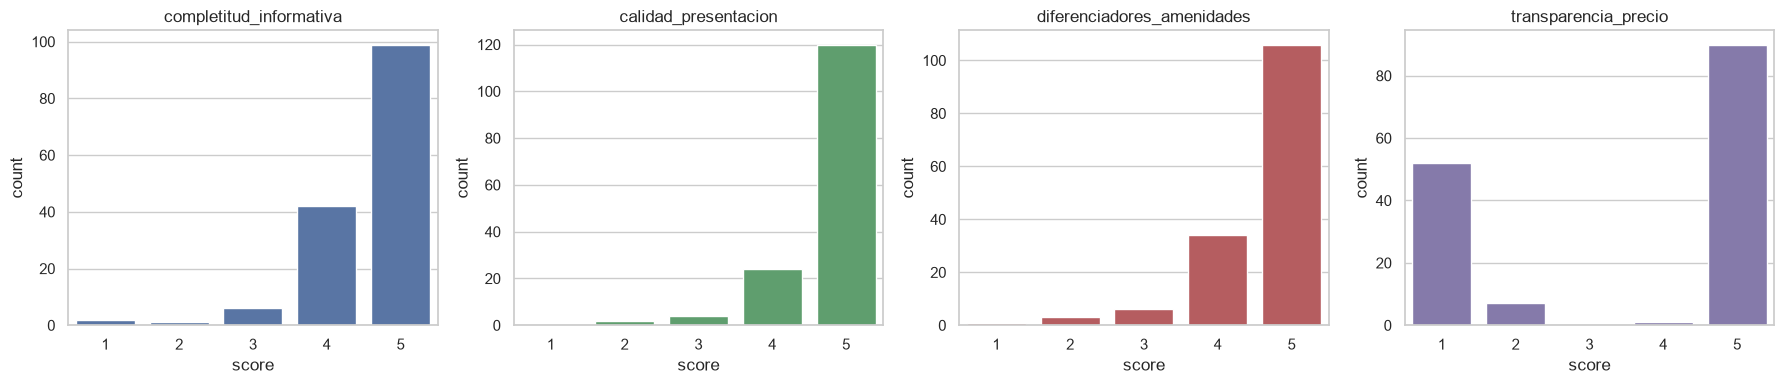

In [10]:
dimensiones = ["completitud_informativa", "calidad_presentacion",
               "diferenciadores_amenidades", "transparencia_precio"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for ax, dim, color in zip(axes, dimensiones, colores):
    sns.countplot(data=df_scores, x=dim, ax=ax, color=color, order=[1, 2, 3, 4, 5])
    ax.set_title(dim)
    ax.set_xlabel("score")
plt.tight_layout()
plt.show()

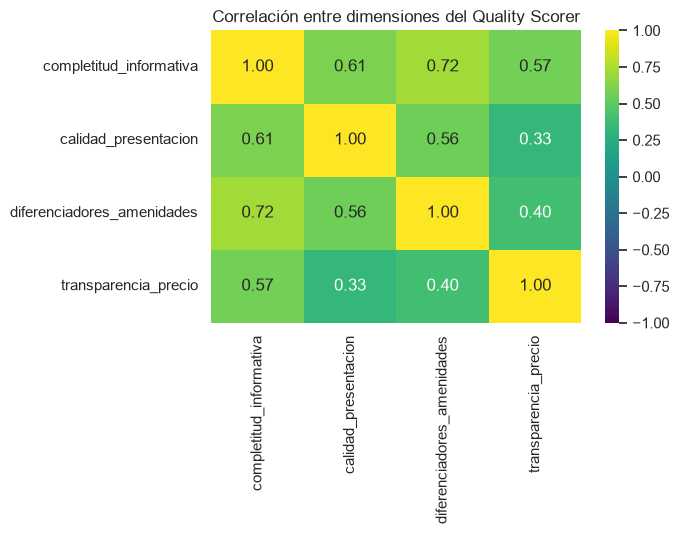

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
corr = df_scores[dimensiones].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlación entre dimensiones del Quality Scorer")
plt.tight_layout()
plt.show()

## 9. Comparación por modelo (gemini-3.5-flash vs. gemini-3-flash-preview)

Como consecuencia del Hallazgo 3 (cambio de modelo a mitad de la corrida por indisponibilidad
sostenida), una parte de la muestra fue evaluada con `gemini-3.5-flash` y el resto con
`gemini-3-flash-preview`. Antes de tratar la muestra como un solo grupo, comparamos media y
desviación estándar de las 4 dimensiones entre ambos subconjuntos -- si son razonablemente
similares, combinar ambos modelos en un solo análisis es metodológicamente razonable; si hay una
diferencia sistemática notable, no la ocultamos dentro del promedio general, la documentamos como
limitación adicional del Hallazgo 3, porque significaría que parte de la variación observada en el
catálogo es artefacto del cambio de modelo, no señal real de calidad de las propiedades.

In [12]:
comparacion_modelos = df_scores.groupby("modelo")[dimensiones].agg(["mean", "std", "count"])
comparacion_modelos

completitud_informativa                  \
                                          mean       std count   
modelo                                                           
gemini-3-flash-preview                4.526316  0.796507    38   
gemini-3.5-flash                      4.580357  0.705683   112   

                       calidad_presentacion                  \
                                       mean       std count   
modelo                                                        
gemini-3-flash-preview             4.789474  0.576939    38   
gemini-3.5-flash                   4.732143  0.569212   112   

                       diferenciadores_amenidades                  \
                                             mean       std count   
modelo                                                              
gemini-3-flash-preview                   4.500000  0.862116    38   
gemini-3.5-flash                         4.642857  0.669236   112   

                       transparencia_precio                  
                                       mean       std count  
modelo                                                       
gemini-3-flash-preview             3.526316  1.870639    38  
gemini-3.5-flash                   3.446429  1.930501   112

In [13]:
diferencias = {}
for dim in dimensiones:
    medias_por_modelo = df_scores.groupby("modelo")[dim].mean()
    if len(medias_por_modelo) == 2:
        diferencias[dim] = medias_por_modelo.max() - medias_por_modelo.min()

print("Diferencia absoluta en la media entre modelos, por dimensión (escala 1-5):")
for dim, diff in diferencias.items():
    print(f"  {dim}: {diff:.2f}")

DIFERENCIA_NOTABLE = 0.5  # en una escala de 1-5, media unidad se considera una brecha sistematica
hay_diferencia_notable = any(d >= DIFERENCIA_NOTABLE for d in diferencias.values())
if hay_diferencia_notable:
    print("\nADVERTENCIA: al menos una dimensión muestra una diferencia de media >= "
          f"{DIFERENCIA_NOTABLE} entre modelos -- ver nota metodológica abajo.")
else:
    print(f"\nNinguna dimensión muestra una diferencia de media >= {DIFERENCIA_NOTABLE} entre "
          "modelos -- las distribuciones son razonablemente similares.")

Diferencia absoluta en la media entre modelos, por dimensión (escala 1-5):
  completitud_informativa: 0.05
  calidad_presentacion: 0.06
  diferenciadores_amenidades: 0.14
  transparencia_precio: 0.08

Ninguna dimensión muestra una diferencia de media >= 0.5 entre modelos -- las distribuciones son razonablemente similares.


**Lectura de la comparación:** si la celda anterior no mostró advertencia, las distribuciones
de los 4 scores entre `gemini-3.5-flash` y `gemini-3-flash-preview` son razonablemente similares
(diferencia de media por debajo de media unidad en una escala de 1-5 en las 4 dimensiones) --
tratamos esto como evidencia de que combinar ambos modelos en un solo análisis no introduce un
sesgo sistemático relevante, y el Hallazgo 3 queda documentado como una limitación de
reproducibilidad (dependencia de un modelo "preview"), no como una limitación de validez de los
resultados. Si la celda mostró advertencia, la diferencia queda registrada explícitamente aquí
como limitación adicional del Hallazgo 3: parte de la variación observada entre listings del
catálogo podría deberse al modelo evaluador y no a diferencias reales de calidad de anuncio, y
cualquier uso futuro de este artifact debería filtrar o controlar por la columna `modelo`.

## 10. % de casos no evaluables

Reportamos el % de listings del catálogo completo que quedan fuera del alcance del Quality Scorer
por no tener texto de `descripcion` (`descripcion_fuente == "ninguna"`), y por separado el % de
fallos técnicos dentro de la muestra evaluada (errores de API o de validación tras el circuit
breaker, no por ausencia de texto).

In [14]:
pct_sin_texto = len(no_evaluables) / total
pct_fallidos_muestra = fallidos / len(resultados_muestra) if resultados_muestra else 0.0

print(f"No evaluables por ausencia de texto (catálogo completo): {len(no_evaluables)} / {total} "
      f"({pct_sin_texto:.2%})")
print(f"Fallidos técnicos dentro de la muestra evaluada: {fallidos} / {len(resultados_muestra)} "
      f"({pct_fallidos_muestra:.2%})")

No evaluables por ausencia de texto (catálogo completo): 9 / 1177 (0.76%)
Fallidos técnicos dentro de la muestra evaluada: 0 / 150 (0.00%)


## 11. Artifacts

Guardamos los scores de la muestra junto con metadata mínima de reproducibilidad (modelo usado,
versión de prompt, semilla de muestreo).

In [15]:
artifact = {
    "df_scores": df_scores,
    "modelo": MODELO_LLM,
    "modelo_version": info_modelo.version,
    "modelos_por_fila": df_scores["modelo"].value_counts().to_dict(),
    "diferencia_media_por_modelo": diferencias,
    "diferencia_notable_entre_modelos": hay_diferencia_notable,
    "thinking_level": "LOW",
    "prompt_version": "v2_structured_output",
    "n_muestra": n,
    "random_state": RANDOM_STATE,
    "tasa_parseo_v1_diagnostico": tasa_v1,
    "tasa_parseo_v2_diagnostico": tasa_v2,
}
with open(RUTA_FINAL, "wb") as f:
    pickle.dump(artifact, f)

print(f"Artifact guardado en {RUTA_FINAL}")

Artifact guardado en /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/pipeline/models/quality_scores_6_2_6_raw.pkl


## Conclusión

Construimos el Quality Scorer de M2 sobre una muestra representativa del catálogo, con un proceso
de iteración de prompt documentado: la versión con salida de texto libre parseada manualmente y la
versión con salida estructurada del SDK, seleccionando esta última por su tasa de validación
superior al umbral de 90%. Las cuatro dimensiones — completitud informativa, calidad de
presentación, diferenciadores/amenidades y transparencia de precio — quedan disponibles como
artifact reusable en `pipeline/models/` para cualquier iteración futura de M2 o M3 que necesite
una señal de calidad de anuncio derivada del texto.